ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df.drop('CUST_ID', axis=1, inplace=True)

**Check the missing values in each column.**

In [8]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
df.fillna(df.mean(), inplace=True)

**Check the missing values again to make sure they were handled.**

In [10]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

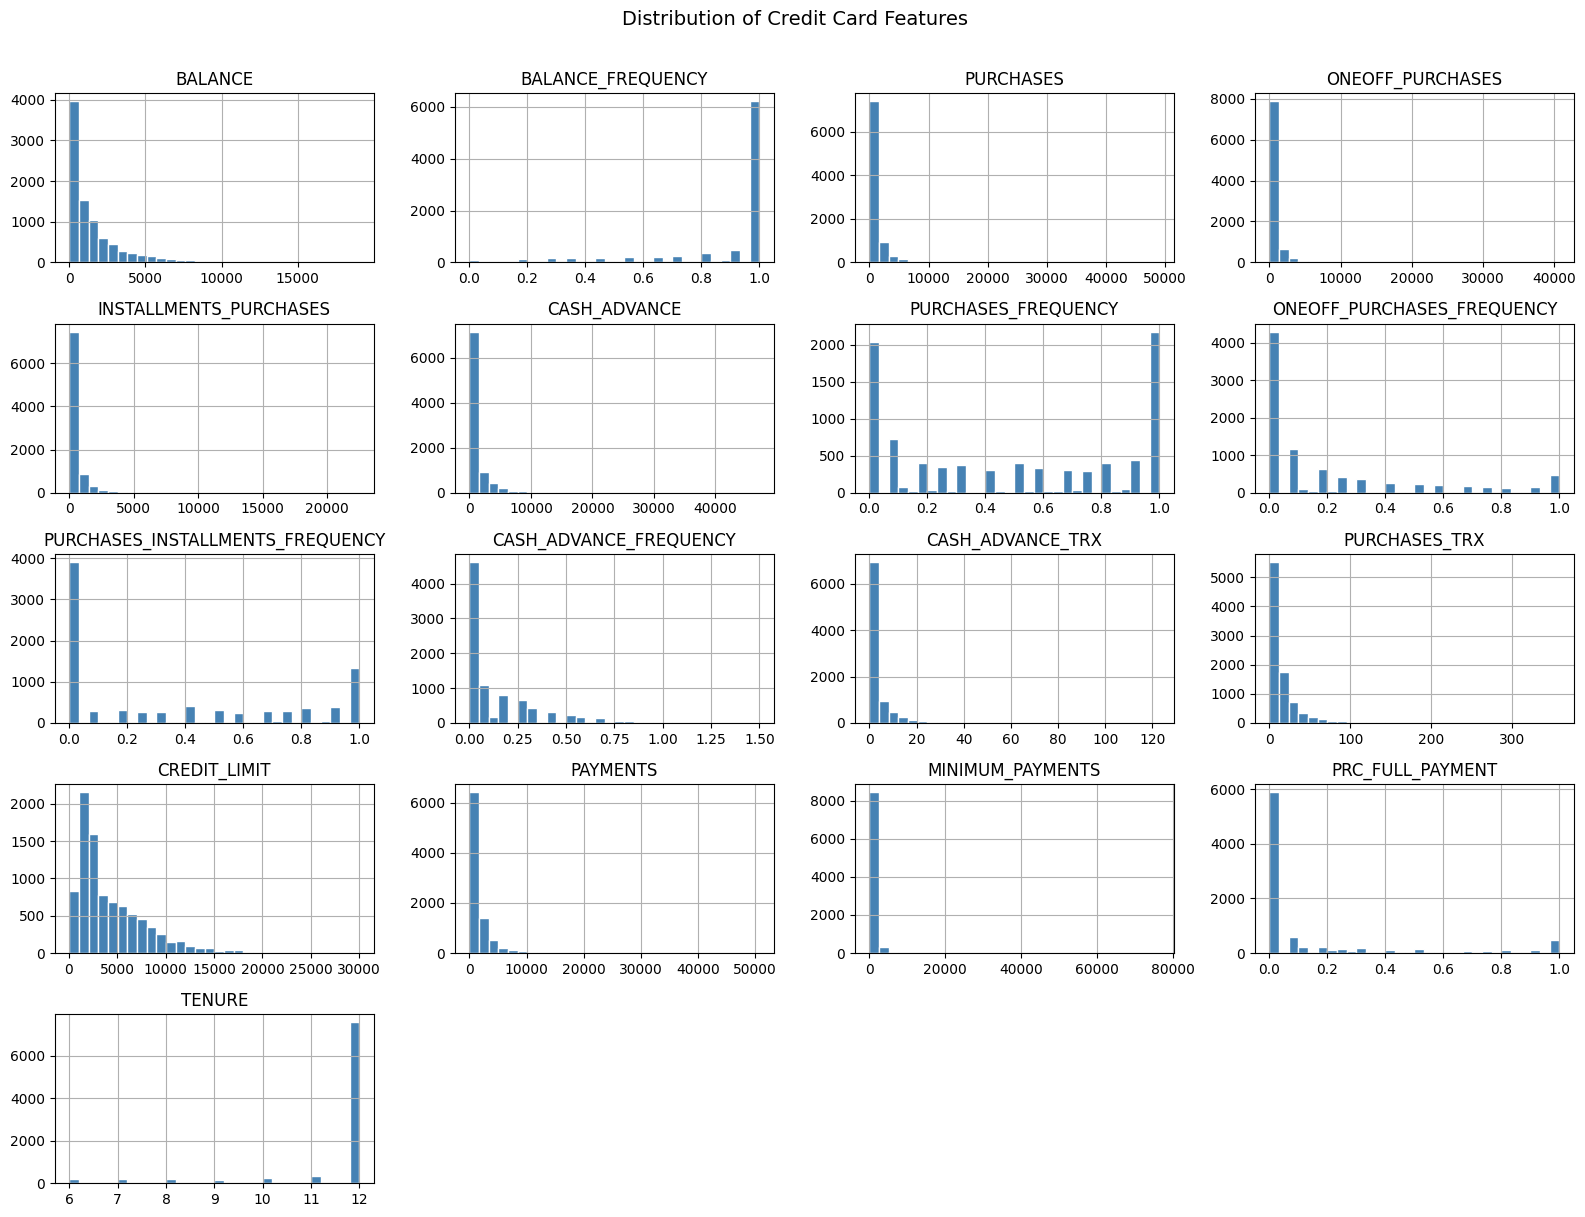

In [11]:
df.hist(figsize=(16, 12), bins=30, color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Credit Card Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

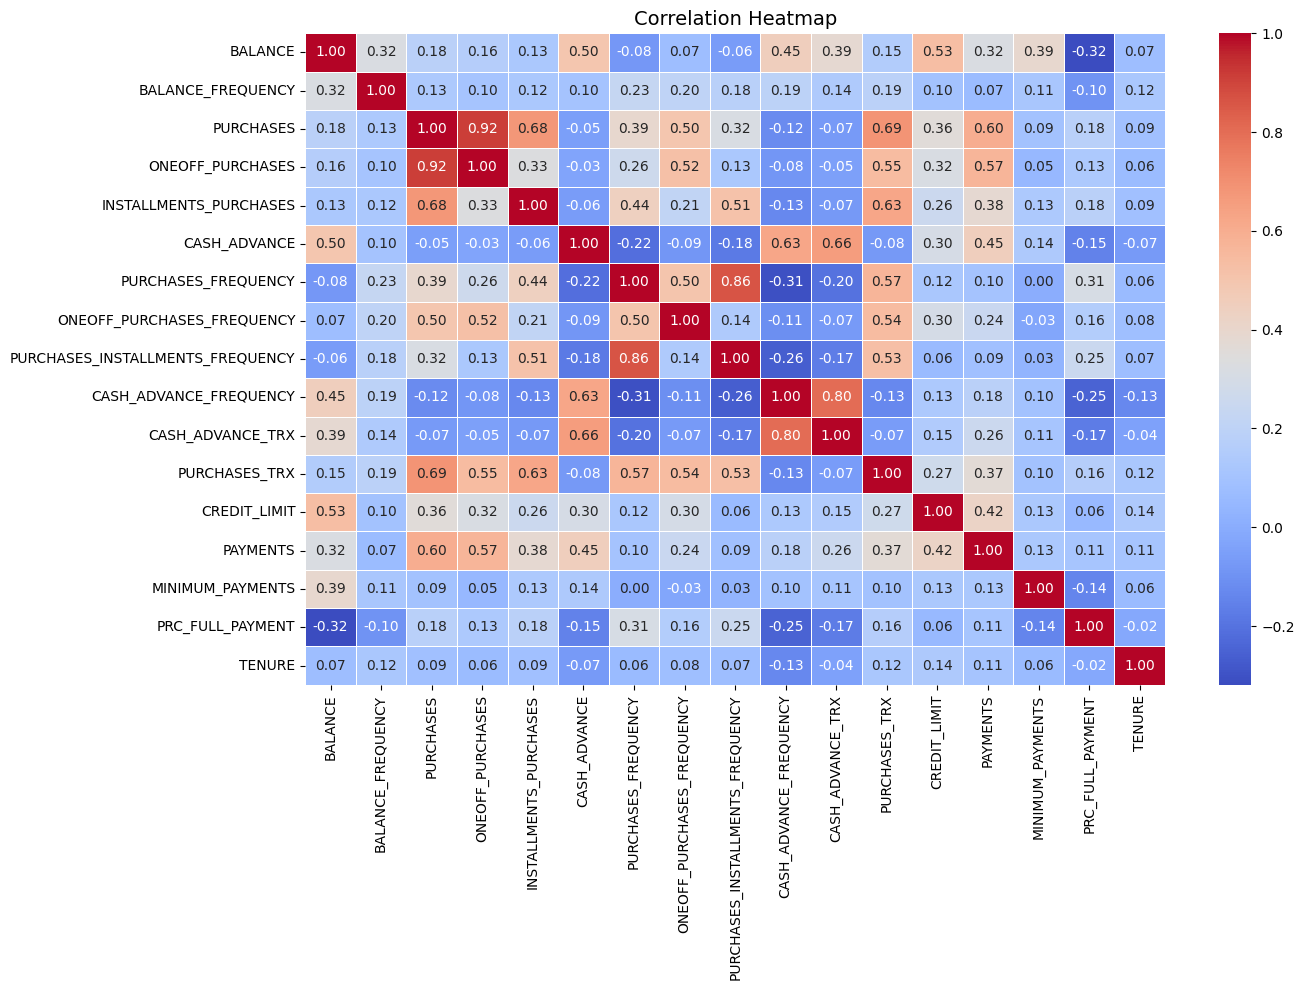

In [12]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

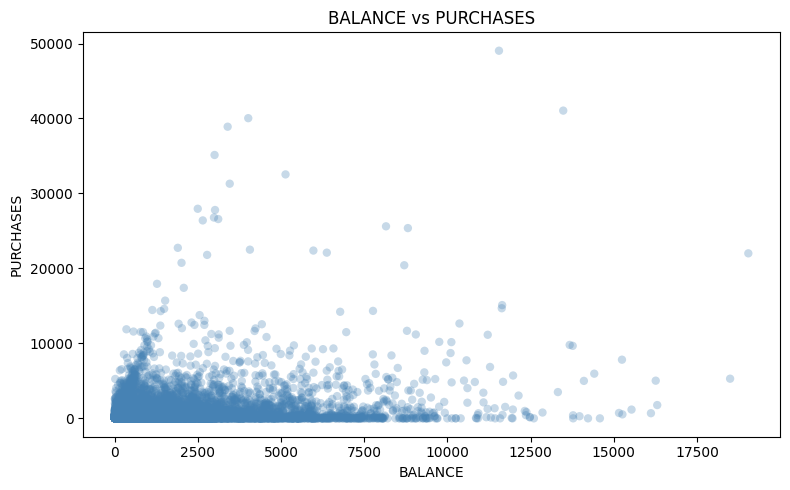

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, color='steelblue', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('PURCHASES')
plt.title('BALANCE vs PURCHASES')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

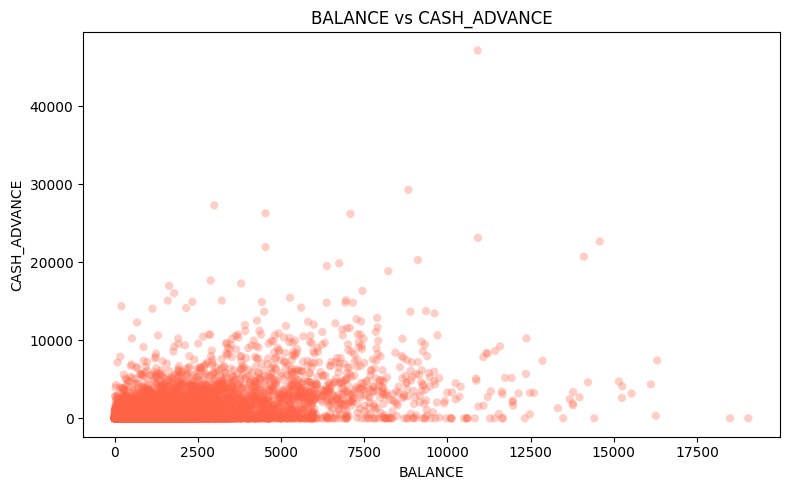

In [14]:
plt.figure(figsize=(8, 5))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, color='tomato', edgecolors='none')
plt.xlabel('BALANCE')
plt.ylabel('CASH_ADVANCE')
plt.title('BALANCE vs CASH_ADVANCE')
plt.tight_layout()
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
inertia_values = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)

**Plot the elbow curve.**

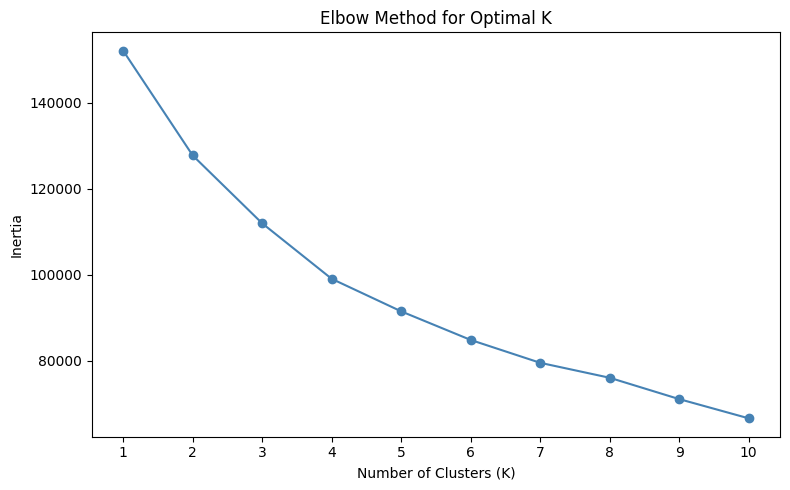

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, marker='o', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
silhouette_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

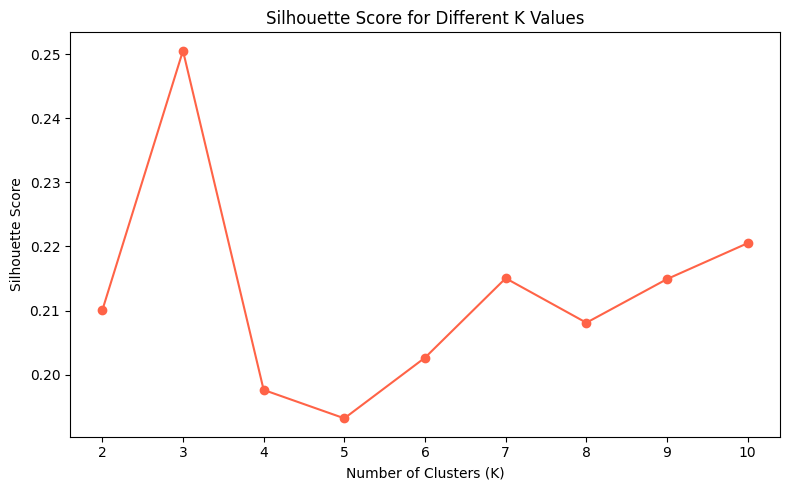

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='tomato')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different K Values')
plt.xticks(range(2, 11))
plt.tight_layout()
plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
silhouette_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': silhouette_scores
})
silhouette_df

,K,Silhouette Score
0,2,0.210033
1,3,0.250556
2,4,0.197607
3,5,0.193169
4,6,0.202639
5,7,0.215038
6,8,0.208092
7,9,0.214912
8,10,0.220518


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
# K=3 gives the highest silhouette score (0.2506) and the elbow curve shows a
# noticeable bend around K=3, making it a strong candidate.
# However, K=4 is also commonly used in credit card segmentation as it provides
# more actionable business segments. We choose K=4 for a balance between
# statistical validity and business interpretability.

final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
df['Cluster'] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
cluster_summary = df.groupby('Cluster').mean().round(2)
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,894.91,0.93,1236.18,593.97,642.48,210.57,0.89,0.30,0.71,0.04,0.79,22.09,4213.21,1332.19,650.17,0.27,11.59
1,3551.15,0.99,7681.62,5095.88,2587.21,653.64,0.95,0.74,0.79,0.07,2.09,89.36,9696.94,7288.74,1976.82,0.29,11.95
2,4602.46,0.97,501.90,320.37,181.61,4520.72,0.29,0.14,0.19,0.48,14.28,7.66,7546.96,3481.15,2008.25,0.03,11.39
3,1011.75,0.79,269.97,209.85,60.39,595.76,0.17,0.09,0.08,0.11,2.13,2.90,3277.70,974.51,586.30,0.08,11.45


**Check how many customers are in each cluster.**

In [25]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,3367
1,409
2,1198
3,3976


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

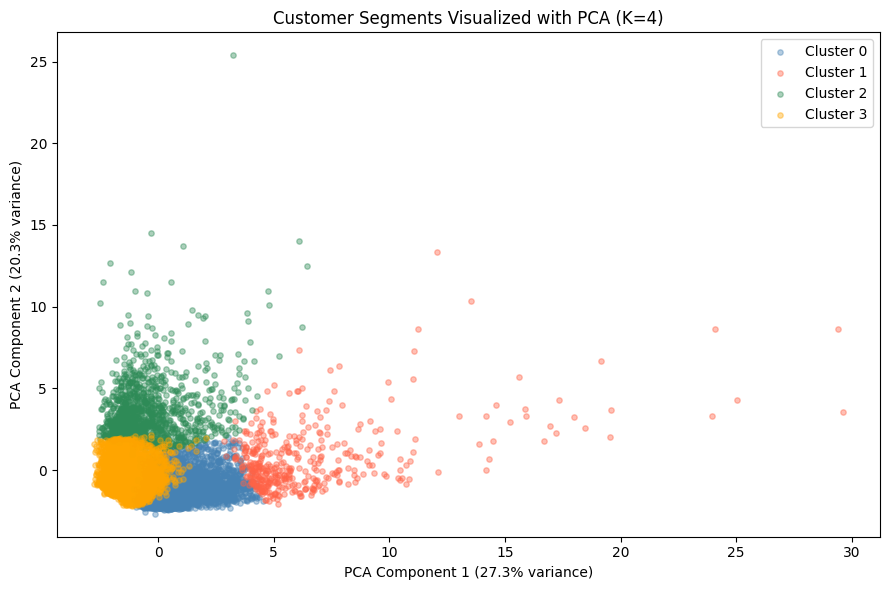

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'orange']
for cluster in range(4):
    mask = df['Cluster'] == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {cluster}',
                alpha=0.4, s=15, color=colors[cluster])

plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer Segments Visualized with PCA (K=4)')
plt.legend()
plt.tight_layout()
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

**1. Why is this an unsupervised learning problem?**

This is an unsupervised learning problem because the dataset does not contain a target variable or predefined labels for customer groups. There is no column telling us which segment each customer belongs to. The model must discover the structure in the data on its own by finding groups of similar customers based on their behavioral features.

---

**2. Why did we remove the `CUST_ID` column?**

We removed `CUST_ID` because it is just an identifier, not a behavioral feature. It carries no meaningful information about how a customer uses their credit card. Including it would add noise to the distance calculations used by K-Means and could distort the clustering results.

---

**3. Which columns had missing values?**

Two columns had missing values:
- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

---

**4. How did you handle the missing values?**

We used mean imputation: we replaced each missing value with the mean of its respective column using `df.fillna(df.mean(), inplace=True)`. This approach preserves all rows and keeps the overall distribution of each feature relatively stable.

---

**5. Why is scaling important before applying K-Means?**

K-Means assigns points to clusters based on Euclidean distance. If one feature has much larger values than another (e.g., `BALANCE` in the thousands vs. `PURCHASES_FREQUENCY` between 0 and 1), the feature with larger values will dominate the distance calculation. Scaling ensures that all features contribute equally to the clustering.

---

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

We chose **K = 4**.

- The elbow curve shows the steepest drop in inertia up to K=3 or K=4, after which the improvement slows significantly — suggesting the elbow is around K=3 to K=4.
- The silhouette score is highest at K=3 (≈0.25), but K=4 still provides a reasonable score (≈0.20) while offering four distinct and more interpretable customer segments that are more useful for business decisions.
- K=4 provides a practical balance between statistical performance and business interpretability in customer segmentation.

---

**7. Based on the cluster summary table, describe each customer segment in your own words.**

- **Cluster 0 – Moderate Purchasers**: These customers have a moderate balance and make a decent amount of purchases. They pay regularly but do not always pay the full amount. They represent a typical, average credit card user.

- **Cluster 1 – High-Value Active Shoppers**: These customers have a high balance and very high purchases, and they also make large payments. They are the most financially active group and likely represent premium or high-income customers who use their card heavily for purchases.

- **Cluster 2 – Cash Advance Reliant**: These customers have a high balance but low purchases. They rely heavily on cash advances rather than purchases. Their full payment rate is very low (3%), suggesting financial stress or dependency on credit.

- **Cluster 3 – Low Activity Customers**: These customers have low balances, very low purchases, low payments, and low overall activity. They are infrequent users who rarely engage with their credit card.

---

**8. Which cluster may represent high-value customers?**

**Cluster 1** represents high-value customers. They have the highest average purchases (~7,682), highest payments (~7,289), and highest credit limits. These are customers who actively use their card for large purchases and make significant payments, making them the most profitable segment for the bank.

---

**9. Which cluster may represent customers who rely more on cash advance?**

**Cluster 2** represents customers who rely heavily on cash advances. They have the highest average `CASH_ADVANCE` value (~4,159) and a very low full payment rate (3%), indicating they frequently withdraw cash using their credit card and struggle to pay off their balance.

---

**10. How can a company use these clusters for marketing strategy?**

- **Cluster 0 (Moderate Purchasers)**: Offer loyalty rewards and cashback programs to encourage them to increase spending and transition toward the high-value segment.
- **Cluster 1 (High-Value Shoppers)**: Offer premium benefits, travel rewards, and exclusive credit limit upgrades to retain them and strengthen loyalty.
- **Cluster 2 (Cash Advance Users)**: Offer financial advisory services, debt consolidation options, or lower-interest products to help them manage debt — reducing risk for the company.
- **Cluster 3 (Low Activity)**: Run re-engagement campaigns with special offers or incentives to activate dormant customers and increase card usage.